In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score)

# Load Data
df = pd.read_csv('fertilizer_recommendation.csv')
df.columns = df.columns.str.strip().str.lower()

In [3]:
df.head()

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,nitrogen_level,phosphorus_level,potassium_level,temperature,humidity,rainfall,crop_type,crop_growth_stage,season,irrigation_type,previous_crop,region,fertilizer_used_last_season,yield_last_season,recommended_fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


Dataset Shape: (10000, 20)
Unique Fertilizers: 7


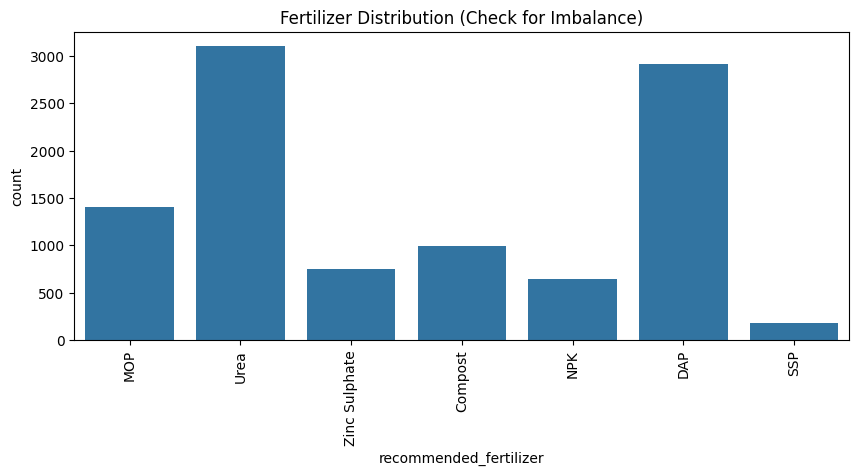

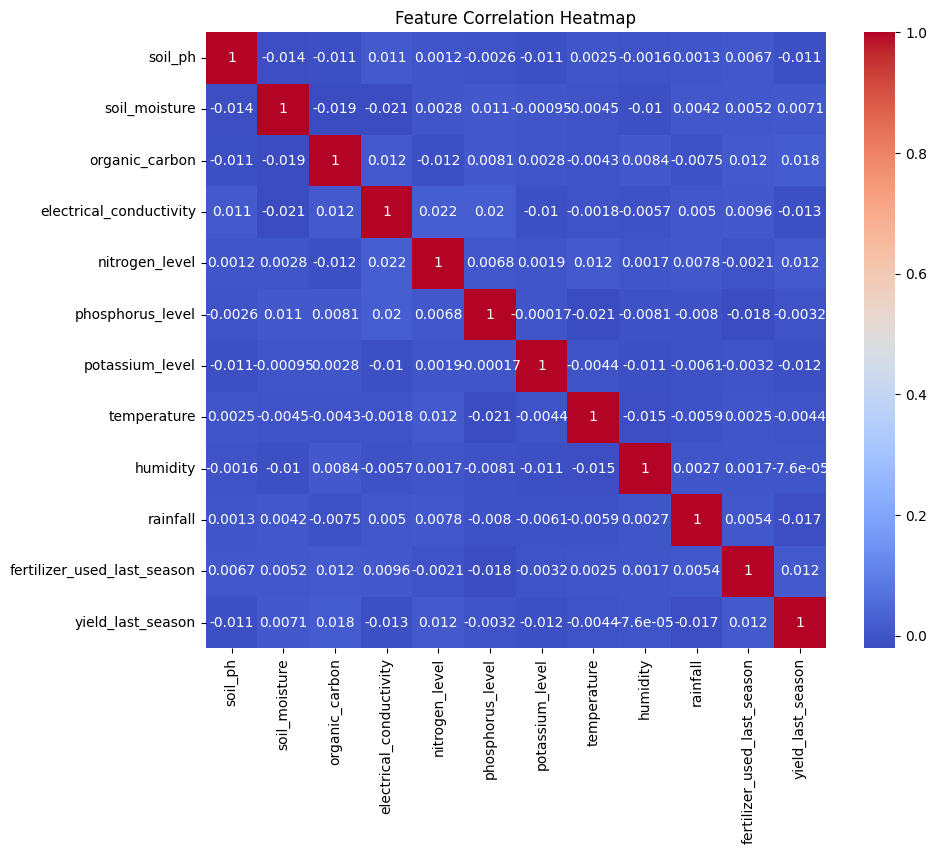

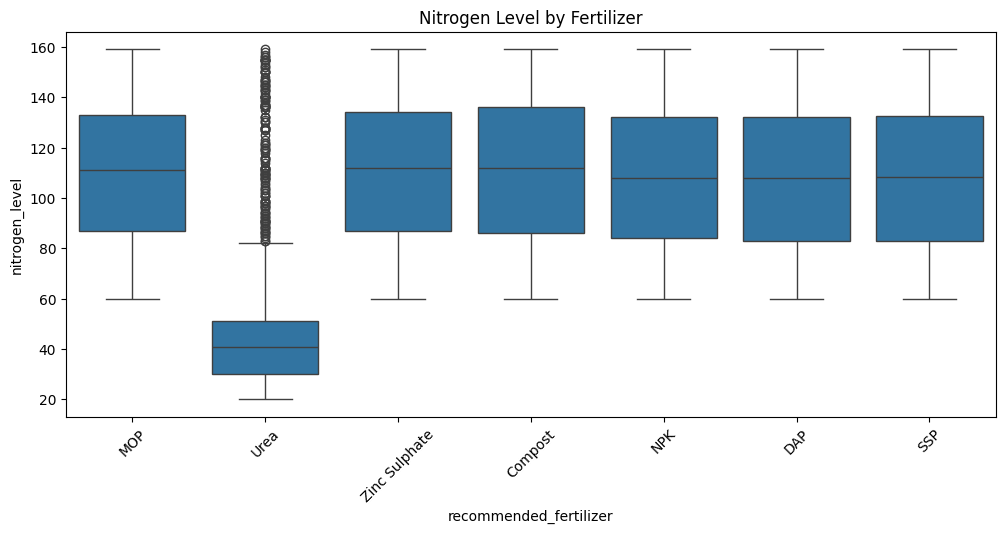

In [4]:
# EDA
print(f"Dataset Shape: {df.shape}")
print(f"Unique Fertilizers: {df['recommended_fertilizer'].nunique()}")

plt.figure(figsize=(10, 4))
sns.countplot(x='recommended_fertilizer', data=df)
plt.xticks(rotation=90)
plt.title("Fertilizer Distribution (Check for Imbalance)")
plt.show()

# Select only numeric columns for the correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='recommended_fertilizer', y='nitrogen_level', data=df)
plt.title("Nitrogen Level by Fertilizer")
plt.xticks(rotation=45)
plt.show()

In [5]:
# Data preparation and splitting

# Encode categorical columns
categorical_cols = ['soil_type', 'crop_type', 'crop_growth_stage', 'season',
                    'irrigation_type', 'previous_crop', 'region']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Separate Features and Target
X = df.drop('recommended_fertilizer', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['recommended_fertilizer'])

# First Split: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second Split: 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

Training set:   7000 samples
Validation set: 1500 samples
Testing set:    1500 samples


In [6]:
# Training the pipeline
results_list = []
trained_pipelines = {}

def evaluate_model(model_obj, name):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model_obj)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv)

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    results_list.append({
        "Model":            name,
        "CV Mean Acc (%)":  round(cv_scores.mean() * 100, 2),
        "CV Std Dev":       round(cv_scores.std(), 4),
        "Val Accuracy (%)": round(accuracy_score(y_val, preds) * 100, 2),
        "Precision":        round(precision_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Recall":           round(recall_score(y_val, preds, average='weighted', zero_division=0), 4),
        "F1 Score":         round(f1_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Kappa":            round(cohen_kappa_score(y_val, preds), 4),
    })

    trained_pipelines[name] = pipe

evaluate_model(LogisticRegression(max_iter=1000), "Logistic Regression")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")
evaluate_model(SVC(kernel='linear'), "SVM (Linear)")
evaluate_model(SVC(kernel='rbf', probability=True), "SVM (RBF)")
evaluate_model(GaussianNB(), "Naive Bayes")

from xgboost import XGBClassifier
evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'), "XGBoost")


df_results = pd.DataFrame(results_list).sort_values(by="CV Mean Acc (%)", ascending=False).reset_index(drop=True)
display(df_results)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:07:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:07:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:07:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:07:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Model,CV Mean Acc (%),CV Std Dev,Val Accuracy (%),Precision,Recall,F1 Score,Kappa
0,Random Forest,88.84,0.0102,86.67,0.8678,0.8667,0.8648,0.8294
1,XGBoost,88.63,0.0083,86.60,0.8664,0.8660,0.8653,0.8282
2,SVM (Linear),80.97,0.0123,79.13,0.7817,0.7913,0.7806,0.7290
3,Logistic Regression,80.63,0.0139,79.20,0.7748,0.7920,0.7813,0.7305
4,Naive Bayes,80.59,0.0102,78.93,0.7764,0.7893,0.7799,0.7262
5,SVM (RBF),79.94,0.0120,77.00,0.7495,0.7700,0.7580,0.7008


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_ * 100, 2), "%")

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 88.76 %


Best model: Random Forest

--- Final Test Set Performance ---
Accuracy  : 89.87%
Precision : 0.8951
Recall    : 0.8987
F1 Score  : 0.8948
Kappa     : 0.8702

✅ Pipeline, LabelEncoder and Encoders saved successfully.


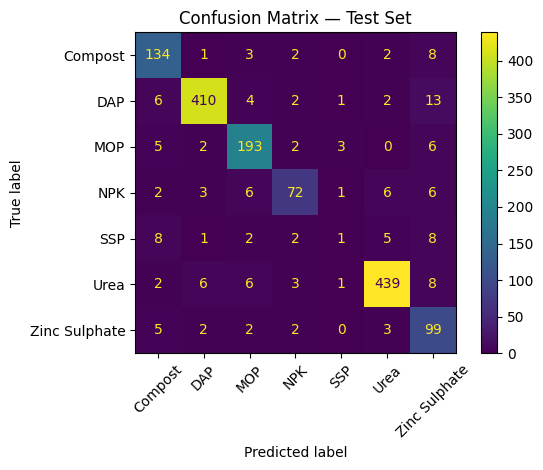

In [8]:
# Exporting the pipeline

# 1. Programmatically select the best model by CV accuracy
best_model_name = df_results.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model: {best_model_name}")

# 2. Final unbiased evaluation on the held-out test set
test_preds = best_pipeline.predict(X_test)
print("\n--- Final Test Set Performance ---")
print(f"Accuracy  : {accuracy_score(y_test, test_preds) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Kappa     : {cohen_kappa_score(y_test, test_preds):.4f}")

# 3. Save the winning pipeline, label encoder and encoders
with open('fertilizer_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("\n✅ Pipeline, LabelEncoder and Encoders saved successfully.")

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=le.classes_, xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

In [10]:
with open('fertilizer_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

categorical_features = ['soil_type', 'crop_type', 'crop_growth_stage', 'season',
                         'irrigation_type', 'previous_crop', 'region']

numeric_features = ['soil_ph', 'soil_moisture', 'organic_carbon', 'electrical_conductivity',
                    'nitrogen_level', 'phosphorus_level', 'potassium_level',
                    'temperature', 'humidity', 'rainfall',
                    'fertilizer_used_last_season', 'yield_last_season']

feature_names = [
    'soil_type', 'soil_ph', 'soil_moisture', 'organic_carbon',
    'electrical_conductivity', 'nitrogen_level', 'phosphorus_level',
    'potassium_level', 'temperature', 'humidity', 'rainfall',
    'crop_type', 'crop_growth_stage', 'season', 'irrigation_type',
    'previous_crop', 'region', 'fertilizer_used_last_season', 'yield_last_season'
]

def production_advisor():
    print("\n" + "="*40)
    print("OFFLINE FERTILIZER ADVISOR (PICKLE LOADED)")
    print("="*40)

    user_inputs = {}
    display_inputs = {}

    for feat in feature_names:
        raw = input(f"Enter {feat}: ")
        if feat in categorical_features:
            raw = raw.strip().lower()
            classes = list(encoders[feat].classes_)
            classes_lower = [c.lower() for c in classes]
            if raw not in classes_lower:
                print(f"Invalid value for '{feat}': '{raw}' not recognized.")
                print(f"  Valid options: {classes}")
                return
            matched = classes[classes_lower.index(raw)]
            user_inputs[feat] = encoders[feat].transform([matched])[0]
            display_inputs[feat] = matched
        else:
            raw = raw.strip()
            try:
                user_inputs[feat] = float(raw)
                display_inputs[feat] = float(raw)
            except ValueError:
                print(f"Invalid input for '{feat}': expected a number, got '{raw}'.")
                return

    print("\n" + "-"*12 + " SUBMITTED DATA " + "-"*12)
    for name, value in display_inputs.items():
        print(f"{name.ljust(30)}: {value}")
    print("-" * 40)

    user_df = pd.DataFrame([user_inputs])[feature_names]
    pred_idx = loaded_pipeline.predict(user_df)[0]
    fertilizer = loaded_le.inverse_transform([pred_idx])[0]

    try:
        prob = np.max(loaded_pipeline.predict_proba(user_df))
        print(f"\nRECOMMENDED FERTILIZER: {fertilizer.upper()}")
        print(f"CONFIDENCE: {prob*100:.2f}%")
    except AttributeError:
        print(f"\nRECOMMENDED FERTILIZER: {fertilizer.upper()}")
    print("="*40)

production_advisor()


OFFLINE FERTILIZER ADVISOR (PICKLE LOADED)


KeyboardInterrupt: Interrupted by user

Dataset Shape: (10000, 20)
Unique Fertilizers: 7


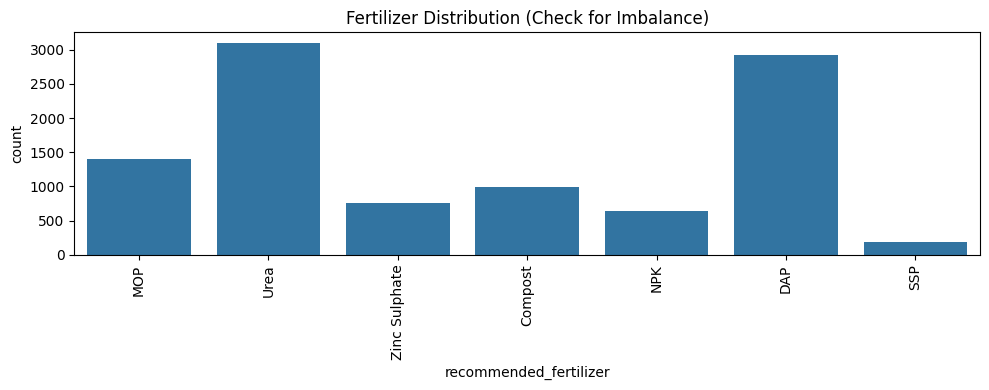

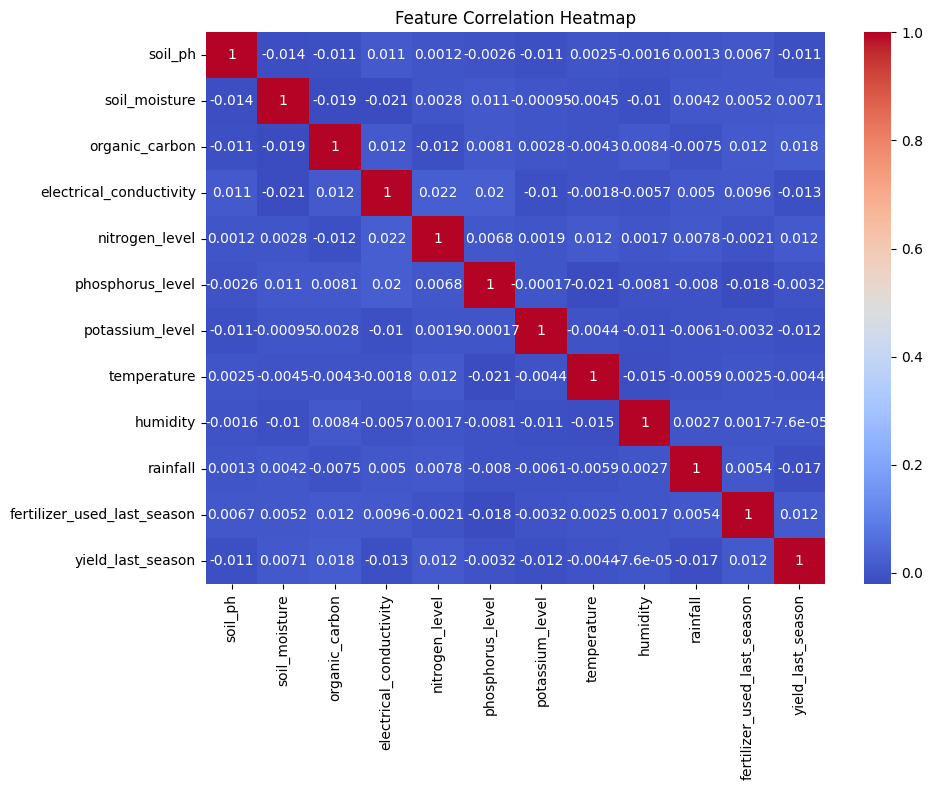

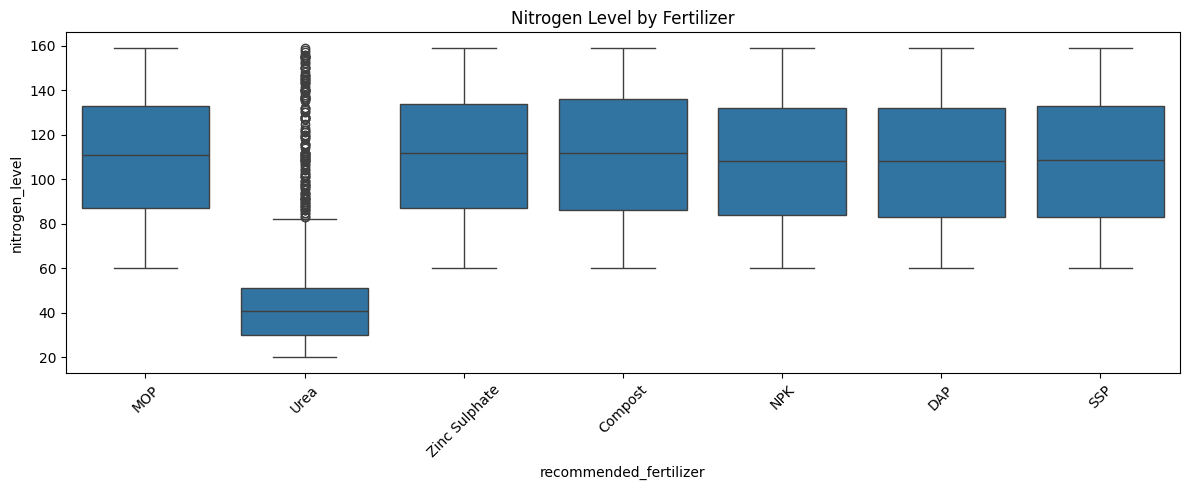


Training set:   7000 samples
Validation set: 1500 samples
Testing set:    1500 samples


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:18:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:18:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:18:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:19:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


               Model  CV Mean Acc (%)  CV Std Dev  Val Accuracy (%)  Precision  Recall  F1 Score  Kappa
       Random Forest            88.79      0.0114             86.07     0.8706  0.8607    0.8627 0.8224
Soft Voting Ensemble            88.63      0.0130             86.13     0.8617  0.8613    0.8595 0.8221
             XGBoost            88.46      0.0101             87.13     0.8724  0.8713    0.8707 0.8349
        SVM (Linear)            81.77      0.0115             80.47     0.8590  0.8047    0.8262 0.7552
 Logistic Regression            81.76      0.0126             79.73     0.8459  0.7973    0.8168 0.7457
           SVM (RBF)            79.71      0.0147             78.07     0.8280  0.7807    0.7997 0.7249
         Naive Bayes            77.57      0.0161             75.93     0.7579  0.7593    0.7567 0.6903

Best model before tuning: Random Forest
Best params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV score after tuning: 8

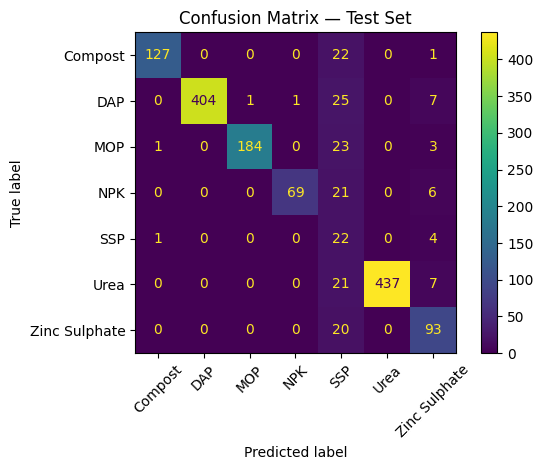


✅ Pipeline and LabelEncoder saved successfully.
   (Categorical encoders are now embedded inside the pipeline — no separate encoders.pkl needed.)

  FERTILIZER RECOMMENDATION ADVISOR

soil_type — valid options: ['Clay', 'Loamy', 'Sandy', 'Silt', 'loamy']


KeyboardInterrupt: Interrupted by user

In [11]:
# -*- coding: utf-8 -*-
"""
fertilizer_recommendation_improved.py
Improved version with better accuracy techniques:
  1. OrdinalEncoder (not LabelEncoder) for categoricals inside the pipeline
  2. Feature engineering (NPK ratios)
  3. Class-weight balancing
  4. Better-tuned XGBoost
  5. Soft-voting ensemble
  6. GridSearch applied to the actual best model
"""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv('fertilizer_recommendation.csv')
df.columns = df.columns.str.strip().str.lower()
print(f"Dataset Shape: {df.shape}")
print(f"Unique Fertilizers: {df['recommended_fertilizer'].nunique()}")

# ─────────────────────────────────────────────
# 2. EDA
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.countplot(x='recommended_fertilizer', data=df)
plt.xticks(rotation=90)
plt.title("Fertilizer Distribution (Check for Imbalance)")
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='recommended_fertilizer', y='nitrogen_level', data=df)
plt.title("Nitrogen Level by Fertilizer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING  ← NEW
#    Domain-meaningful ratios help tree models
#    find better decision boundaries.
# ─────────────────────────────────────────────
df['npk_ratio']  = df['nitrogen_level'] / (df['phosphorus_level'] + df['potassium_level'] + 1e-6)
df['n_p_ratio']  = df['nitrogen_level']  / (df['phosphorus_level'] + 1e-6)
df['p_k_ratio']  = df['phosphorus_level'] / (df['potassium_level']  + 1e-6)

# ─────────────────────────────────────────────
# 4. DEFINE FEATURE GROUPS
# ─────────────────────────────────────────────
categorical_cols = ['soil_type', 'crop_type', 'crop_growth_stage', 'season',
                    'irrigation_type', 'previous_crop', 'region']

numeric_features = [
    'soil_ph', 'soil_moisture', 'organic_carbon', 'electrical_conductivity',
    'nitrogen_level', 'phosphorus_level', 'potassium_level',
    'temperature', 'humidity', 'rainfall',
    'fertilizer_used_last_season', 'yield_last_season',
    'npk_ratio', 'n_p_ratio', 'p_k_ratio'          # engineered features
]

feature_names = categorical_cols + numeric_features  # keep a stable order

# ─────────────────────────────────────────────
# 5. TARGET ENCODING
# ─────────────────────────────────────────────
le_target = LabelEncoder()
y = le_target.fit_transform(df['recommended_fertilizer'])
X = df[feature_names].copy()

# ─────────────────────────────────────────────
# 6. TRAIN / VAL / TEST SPLIT  (70 / 15 / 15)
# ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTraining set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

# ─────────────────────────────────────────────
# 7. PREPROCESSOR  ← NEW
#    OrdinalEncoder for categoricals keeps the
#    encoding inside the pipeline (no data leakage,
#    handles unseen categories gracefully).
# ─────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     categorical_cols),
    ('num', StandardScaler(), numeric_features)
])

# ─────────────────────────────────────────────
# 8. MODEL TRAINING
# ─────────────────────────────────────────────
results_list   = []
trained_pipelines = {}

def evaluate_model(model_obj, name):
    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', model_obj)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    results_list.append({
        "Model":            name,
        "CV Mean Acc (%)":  round(cv_scores.mean() * 100, 2),
        "CV Std Dev":       round(cv_scores.std(), 4),
        "Val Accuracy (%)": round(accuracy_score(y_val, preds) * 100, 2),
        "Precision":        round(precision_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Recall":           round(recall_score(y_val, preds, average='weighted', zero_division=0), 4),
        "F1 Score":         round(f1_score(y_val, preds, average='weighted', zero_division=0), 4),
        "Kappa":            round(cohen_kappa_score(y_val, preds), 4),
    })
    trained_pipelines[name] = pipe

# -- Logistic Regression (balanced weights handle class imbalance) --
evaluate_model(
    LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0),
    "Logistic Regression")

# -- Random Forest (balanced) --
evaluate_model(
    RandomForestClassifier(n_estimators=200, random_state=42,
                           class_weight='balanced', n_jobs=-1),
    "Random Forest")

# -- SVM Linear (balanced) --
evaluate_model(
    SVC(kernel='linear', class_weight='balanced'),
    "SVM (Linear)")

# -- SVM RBF (balanced, probability for ensemble) --
evaluate_model(
    SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "SVM (RBF)")

# -- Naive Bayes --
evaluate_model(GaussianNB(), "Naive Bayes")

# -- XGBoost (better hyperparams than defaults) ← IMPROVED --
evaluate_model(
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        n_jobs=-1
    ),
    "XGBoost")

# -- Soft Voting Ensemble (RF + XGB + SVM-RBF)  ← NEW --
rf_clf  = RandomForestClassifier(n_estimators=200, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
xgb_clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, eval_metric='mlogloss',
                         use_label_encoder=False, n_jobs=-1)
svm_clf = SVC(kernel='rbf', probability=True, class_weight='balanced')

voting_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('svm', svm_clf)],
    voting='soft'
)
evaluate_model(voting_clf, "Soft Voting Ensemble")

# ─────────────────────────────────────────────
# 9. RESULTS TABLE
# ─────────────────────────────────────────────
df_results = (pd.DataFrame(results_list)
              .sort_values(by="CV Mean Acc (%)", ascending=False)
              .reset_index(drop=True))
print("\n" + "="*60)
print(df_results.to_string(index=False))
print("="*60)

# ─────────────────────────────────────────────
# 10. HYPERPARAMETER TUNING ON THE BEST MODEL  ← IMPROVED
#     Previously hardcoded to RandomForest.
#     Now targets the actual winner.
# ─────────────────────────────────────────────
best_model_name = df_results.iloc[0]["Model"]
best_pipeline   = trained_pipelines[best_model_name]
print(f"\nBest model before tuning: {best_model_name}")

# Define param grids per model type
param_grids = {
    "Random Forest": {
        'model__n_estimators':   [100, 200, 300],
        'model__max_depth':      [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'model__n_estimators':  [200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth':     [4, 6, 8]
    },
    "Soft Voting Ensemble": None,   # ensembles are expensive to grid-search; skip
    "Logistic Regression": {
        'model__C': [0.01, 0.1, 1.0, 10.0]
    },
    "SVM (RBF)": {
        'model__C':     [0.1, 1, 10],
        'model__gamma': ['scale', 'auto']
    },
}

grid_param = param_grids.get(best_model_name)
if grid_param:
    grid = GridSearchCV(best_pipeline, grid_param,
                        cv=5, scoring='accuracy', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV score after tuning: {round(grid.best_score_ * 100, 2)}%")
    best_pipeline = grid.best_estimator_
else:
    print("Skipping GridSearch for ensemble (computationally expensive).")

# ─────────────────────────────────────────────
# 11. FINAL TEST-SET EVALUATION
# ─────────────────────────────────────────────
test_preds = best_pipeline.predict(X_test)
print("\n--- Final Test Set Performance ---")
print(f"Accuracy  : {accuracy_score(y_test, test_preds) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Kappa     : {cohen_kappa_score(y_test, test_preds):.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds,
    display_labels=le_target.classes_,
    xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 12. SAVE ARTIFACTS
#     Only the pipeline + target label encoder needed now.
#     Categorical encoding is INSIDE the pipeline.
# ─────────────────────────────────────────────
with open('fertilizer_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print("\n✅ Pipeline and LabelEncoder saved successfully.")
print("   (Categorical encoders are now embedded inside the pipeline — no separate encoders.pkl needed.)")

# ─────────────────────────────────────────────
# 13. PRODUCTION ADVISOR  ← CLEANER
#     No manual encoding step — pipeline handles it.
# ─────────────────────────────────────────────
with open('fertilizer_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

# Build valid-values lookup for categorical inputs from training data
valid_values = {col: sorted(df[col].dropna().unique().tolist()) for col in categorical_cols}

def production_advisor():
    print("\n" + "="*45)
    print("  FERTILIZER RECOMMENDATION ADVISOR")
    print("="*45)

    user_inputs    = {}
    display_inputs = {}

    for feat in feature_names:
        if feat in ['npk_ratio', 'n_p_ratio', 'p_k_ratio']:
            continue  # computed automatically below

        if feat in categorical_cols:
            options = valid_values[feat]
            print(f"\n{feat} — valid options: {options}")
            raw = input(f"Enter {feat}: ").strip()
            # Case-insensitive match
            matched = next((v for v in options if str(v).lower() == raw.lower()), None)
            if matched is None:
                print(f"  ✗ '{raw}' not recognised. Valid: {options}")
                return
            user_inputs[feat]    = matched
            display_inputs[feat] = matched
        else:
            raw = input(f"Enter {feat}: ").strip()
            try:
                user_inputs[feat]    = float(raw)
                display_inputs[feat] = float(raw)
            except ValueError:
                print(f"  ✗ Expected a number for '{feat}', got '{raw}'.")
                return

    # Compute engineered features
    n = user_inputs['nitrogen_level']
    p = user_inputs['phosphorus_level']
    k = user_inputs['potassium_level']
    user_inputs['npk_ratio'] = n / (p + k + 1e-6)
    user_inputs['n_p_ratio'] = n / (p + 1e-6)
    user_inputs['p_k_ratio'] = p / (k + 1e-6)

    print("\n" + "-"*14 + " SUBMITTED DATA " + "-"*14)
    for name, value in display_inputs.items():
        print(f"  {name.ljust(32)}: {value}")
    print("-" * 44)

    user_df  = pd.DataFrame([user_inputs])[feature_names]
    pred_idx = loaded_pipeline.predict(user_df)[0]
    fertilizer = loaded_le.inverse_transform([pred_idx])[0]

    try:
        prob = np.max(loaded_pipeline.predict_proba(user_df))
        print(f"\n  RECOMMENDED FERTILIZER : {fertilizer.upper()}")
        print(f"  CONFIDENCE             : {prob * 100:.2f}%")
    except AttributeError:
        print(f"\n  RECOMMENDED FERTILIZER : {fertilizer.upper()}")
    print("="*45)

production_advisor()